In [2]:
# Install datasets Library
# !pip install datasts

import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

#Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\chimc\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<Axes: xlabel='job_title_short'>

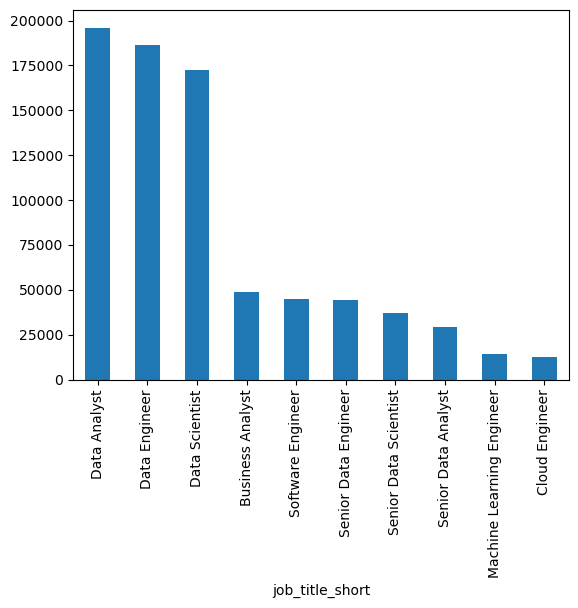

In [3]:
fig, ax = plt.subplots()

df['job_title_short'].value_counts().plot(kind='bar', ax=ax) # Plotting the count of each job title

In [4]:
df['job_schedule_type'].value_counts().head(5)

job_schedule_type
Full-time                  701727
Contractor                  34793
Internship                   8742
Part-time                    7881
Full-time and Part-time      6287
Name: count, dtype: int64

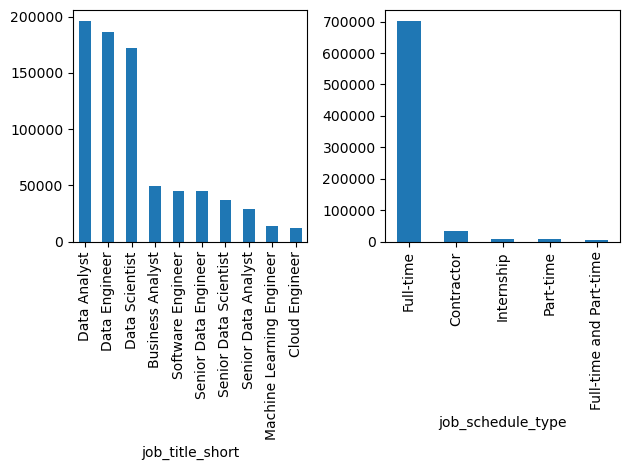

In [5]:
fig, ax = plt.subplots(1, 2)

df['job_title_short'].value_counts().plot(kind='bar', ax=ax[0])
df['job_schedule_type'].value_counts().head(5).plot(kind='bar', ax=ax[1])

fig.tight_layout()


Below uses Matplot

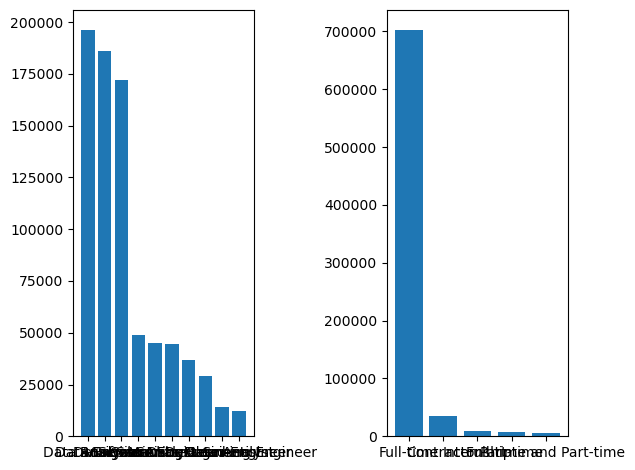

In [6]:
fig, ax = plt.subplots(1, 2)

ax[0].bar(df['job_title_short'].value_counts().index, df['job_title_short'].value_counts().values)
ax[1].bar(df['job_schedule_type'].value_counts().head(5).index, df['job_schedule_type'].value_counts().head(5).values)

fig.tight_layout()

In [10]:
df_skills = df.copy()
df_skills = df_skills.explode('job_skills')
skills_counts = df_skills.groupby(['job_skills', 'job_title_short']).size()
df_skills_count = skills_counts.reset_index(name='skill_count')
df_skills_count.sort_values(by='skill_count', ascending=False, inplace=True)

df_skills_count

,job_skills,job_title_short,skill_count
1480,python,Data Scientist,113711
1822,sql,Data Engineer,113130
1479,python,Data Engineer,108022
1821,sql,Data Analyst,92428
1823,sql,Data Scientist,78982
...,...,...,...
2173,webex,Senior Data Scientist,1
293,codecommit,Business Analyst,1
2233,xamarin,Machine Learning Engineer,1
1087,mlr,Machine Learning Engineer,1


In [7]:
job_titles = ['Data Scientist', 'Data Engineer', 'Data Analyst']

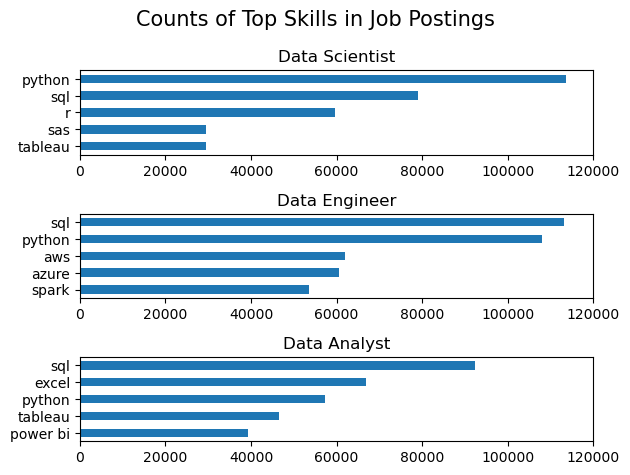

In [20]:
fig, ax = plt.subplots(3,1)

for i, job_title in enumerate(job_titles):
    df_plot =df_skills_count[df_skills_count['job_title_short'] == job_title].head(5)
    df_plot.plot(kind='barh', x='job_skills', y='skill_count', ax=ax[i], title=job_title)
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False)
    ax[i].set_xlim(0, 120000)



fig.suptitle('Counts of Top Skills in Job Postings', fontsize=15)

fig.tight_layout()